# Auto Recall Dataset — Data Cleaning & Feature Engineering

**Dataset**: NHTSA vehicle recall data from the U.S. government website  
**Goal**: Clean messy data **without hardcoding** anything, then apply feature engineering techniques  

---

## How to Run This Notebook

1. Make sure you have Python installed
2. Install the required packages by running the first code cell below
3. Click each cell and press **Shift + Enter** to run it top-to-bottom
4. Read the markdown explanations — they describe every step in plain English

In [35]:
# ── Install required packages (run once) ──
# If any are missing, this cell will install them for you.
import subprocess, sys

packages = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "statsmodels", "category_encoders"]
for pkg in packages:
    try:
        __import__(pkg.replace("-", "_").split("==")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages ready!")

All packages ready!


In [36]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Make plots look nice
sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 80)

print("Imports loaded.")

Imports loaded.


---
# TASK 1: Data Cleaning

We will clean the data **programmatically** — Python decides what to fix based on
what it finds in the data.  Nothing is hardcoded.

## 1.1  Load the Raw Data

In [37]:
# Load the CSV
df_raw = pd.read_csv("Auto Recall Dataset.csv", low_memory=False)

print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
df_raw.head(3)

Rows: 29,663
Columns: 15


,Report Received Date,NHTSA ID,Recall Link,Manufacturer,Subject,Component,Mfr Campaign Number,Recall Type,Potentially Affected,Recall Description,Consequence Summary,Corrective Action,Park Outside Advisory,Do Not Drive Advisory,Completion Rate % (Blank - Not Reported)
0,01/06/2026,26V004000,Go to Recall (https://www.nhtsa.gov/recalls?nhtsaId=26V004000),Blue Bird Body Company,Wheelchair Restraint Retractor May Not Lock,EQUIPMENT ADAPTIVE/MOBILITY,NaN,Vehicle,11,Blue Bird Bus Company (Blue Bird) is recalling certain 2026 Vision and All A...,"An unsecured wheelchair can move during transit, increasing the risk of injury.",Blue Bird will work with Q'Straint to inspect and replace the retractors as ...,No,No,NaN
1,01/05/2026,26E001000,Go to Recall (https://www.nhtsa.gov/recalls?nhtsaId=26E001000),Allwin Powersports Corp.,Helmets May Not Adequately Protect User/FMVSS 218,EQUIPMENT,NaN,Equipment,"3,714","Allwin Powersports Corp. (APC) is recalling certain LS2 Rebellion helmets, s...",A helmet that does not provide adequate protection increases the risk of inj...,"APC will replace the helmet, free of charge. Owners may contact APC customer...",No,No,NaN
2,01/05/2026,26V002000,Go to Recall (https://www.nhtsa.gov/recalls?nhtsaId=26V002000),Blue Bird Body Company,Loose 12-Volt Cable May Cause Loss Of Drive Power and Electrical System,ELECTRICAL SYSTEM,NaN,Vehicle,16,Blue Bird Bus Company (Blue Bird) is recalling certain 2022-2024 All America...,"A loss of brake assist, drive power, steering assist, or instrument panel di...","Dealers will inspect, add a torque stripe, and properly tighten the 12-volt ...",No,No,NaN


In [38]:
# Quick overview of every column: data type, unique values, missing count
summary = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "unique": df_raw.nunique(),
    "missing": df_raw.isnull().sum(),
    "missing_%": (df_raw.isnull().mean() * 100).round(1),
    "sample_value": df_raw.iloc[0],
})
summary

,dtype,unique,missing,missing_%,sample_value
Report Received Date,object,10265,0,0.0,01/06/2026
NHTSA ID,object,29663,0,0.0,26V004000
Recall Link,object,29663,0,0.0,Go to Recall (https://www.nhtsa.gov/recalls?nhtsaId=26V004000)
Manufacturer,object,3065,0,0.0,Blue Bird Body Company
Subject,object,17105,0,0.0,Wheelchair Restraint Retractor May Not Lock
Component,object,35,7565,25.5,EQUIPMENT ADAPTIVE/MOBILITY
Mfr Campaign Number,object,12111,208,0.7,NaN
Recall Type,object,4,0,0.0,Vehicle
Potentially Affected,object,10216,0,0.0,11
Recall Description,object,26513,2401,8.1,Blue Bird Bus Company (Blue Bird) is recalling certain 2026 Vision and All A...


## 1.2  Fix Column Names

**What we're fixing**: Column names sometimes have trailing spaces, inconsistent
casing, or special characters that make them hard to work with.  
**How**: We strip whitespace, lowercase everything, and replace spaces/special chars with underscores.  
**Why**: Clean column names prevent typos and make code easier to read.

In [39]:
df = df_raw.copy()  # Always work on a copy so we can compare back to the original

# Programmatically clean ALL column names
# - strip leading/trailing whitespace
# - lowercase
# - replace spaces and special characters with underscores
# - collapse multiple underscores
import re

def clean_col_name(name):
    """Turn any messy column name into a clean snake_case name."""
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)  # replace non-alphanumeric with _
    name = name.strip("_")                     # remove leading/trailing _
    return name

old_names = df.columns.tolist()
df.columns = [clean_col_name(c) for c in df.columns]

# Show what changed
renamed = [(o, n) for o, n in zip(old_names, df.columns) if o != n]
if renamed:
    print(f"{len(renamed)} column(s) renamed:")
    for old, new in renamed:
        print(f"  '{old}'  →  '{new}'")
else:
    print("No columns needed renaming.")

print(f"\nFinal columns: {df.columns.tolist()}")

15 column(s) renamed:
  'Report Received Date'  →  'report_received_date'
  'NHTSA ID'  →  'nhtsa_id'
  'Recall Link'  →  'recall_link'
  'Manufacturer'  →  'manufacturer'
  'Subject'  →  'subject'
  'Component'  →  'component'
  'Mfr Campaign Number'  →  'mfr_campaign_number'
  'Recall Type'  →  'recall_type'
  'Potentially Affected'  →  'potentially_affected'
  'Recall Description'  →  'recall_description'
  'Consequence Summary'  →  'consequence_summary'
  'Corrective Action'  →  'corrective_action'
  'Park Outside Advisory '  →  'park_outside_advisory'
  'Do Not Drive Advisory'  →  'do_not_drive_advisory'
  'Completion Rate % (Blank - Not Reported)'  →  'completion_rate_blank_not_reported'

Final columns: ['report_received_date', 'nhtsa_id', 'recall_link', 'manufacturer', 'subject', 'component', 'mfr_campaign_number', 'recall_type', 'potentially_affected', 'recall_description', 'consequence_summary', 'corrective_action', 'park_outside_advisory', 'do_not_drive_advisory', 'completion

## 1.3  Fix Data Types

Several columns are stored as plain text (`object`) but actually represent
**dates**, **numbers**, or **yes/no flags**.  Python auto-detects what each column
should be — no hardcoding needed.

### 1.3a  Parse Dates

**What**: `report_received_date` is a string like `"01/06/2026"`.  
**Fix**: Convert it to a real datetime so we can do math (e.g., how old is each recall?).  
**How**: We auto-detect which columns look like dates.

In [40]:
# Auto-detect date columns: try parsing every 'object' column as a date.
# If >80% of non-null values parse successfully, treat it as a date column.

date_cols_found = []
for col in df.select_dtypes(include="object").columns:
    sample = df[col].dropna().head(200)  # sample for speed
    try:
        parsed = pd.to_datetime(sample, format="mixed", dayfirst=False)
        success_rate = parsed.notna().mean()
        if success_rate > 0.8:
            date_cols_found.append(col)
    except Exception:
        pass

for col in date_cols_found:
    df[col] = pd.to_datetime(df[col], format="mixed", dayfirst=False, errors="coerce")

print(f"Date columns detected and converted: {date_cols_found}")
if date_cols_found:
    print(f"Date range: {df[date_cols_found[0]].min()} to {df[date_cols_found[0]].max()}")

Date columns detected and converted: ['report_received_date']
Date range: 1966-01-19 00:00:00 to 2026-01-06 00:00:00


### 1.3b  Parse Numbers with Commas

**What**: `potentially_affected` has values like `"3,714"` and `"413,151"` — they
look like numbers but the commas make Python read them as text.  
**Fix**: Strip commas, then convert to numeric.  
**How**: We auto-detect every text column that becomes numeric after removing commas.

In [41]:
# Auto-detect text columns that are really numbers with commas
numeric_converted = []

for col in df.select_dtypes(include="object").columns:
    # Strip commas and try converting to numeric
    cleaned = df[col].astype(str).str.replace(",", "", regex=False).str.strip()
    as_numeric = pd.to_numeric(cleaned, errors="coerce")
    
    # If >80% of non-null values convert to numbers, treat as numeric
    non_null_mask = df[col].notna()
    if non_null_mask.sum() > 0:
        success_rate = as_numeric[non_null_mask].notna().mean()
        if success_rate > 0.8:
            df[col] = as_numeric
            numeric_converted.append(col)

print(f"Columns converted from text to numeric: {numeric_converted}")
for col in numeric_converted:
    print(f"  {col}: min={df[col].min()}, max={df[col].max():,.0f}, mean={df[col].mean():,.1f}")

Columns converted from text to numeric: ['potentially_affected', 'completion_rate_blank_not_reported']
  potentially_affected: min=0, max=32,000,000, mean=45,172.6
  completion_rate_blank_not_reported: min=0.0, max=3,380, mean=69.7


### 1.3c  Detect and Convert Yes/No Columns to Boolean

**What**: Columns like `park_outside_advisory` and `do_not_drive_advisory` only
contain `"Yes"` and `"No"`.  
**Fix**: Convert to `True`/`False` (boolean), which is more efficient and
makes analysis easier.  
**How**: We auto-detect any column whose unique values are a subset of common
yes/no patterns.

In [42]:
# Auto-detect Yes/No columns
YES_VALUES = {"yes", "y", "true", "1"}
NO_VALUES  = {"no", "n", "false", "0"}

bool_converted = []
for col in df.select_dtypes(include="object").columns:
    unique_vals = set(df[col].dropna().str.strip().str.lower().unique())
    if unique_vals and unique_vals.issubset(YES_VALUES | NO_VALUES):
        df[col] = df[col].str.strip().str.lower().isin(YES_VALUES)
        bool_converted.append(col)

print(f"Boolean columns detected and converted: {bool_converted}")
for col in bool_converted:
    print(f"  {col}: True={df[col].sum():,}, False={(~df[col]).sum():,}")

Boolean columns detected and converted: ['park_outside_advisory', 'do_not_drive_advisory']
  park_outside_advisory: True=84, False=29,579
  do_not_drive_advisory: True=187, False=29,476


## 1.4  Handle Missing Values

**Strategy** (decided automatically based on % missing):
- **> 50% missing** → Drop the column (too unreliable)
- **Categorical columns** → Fill with `"Unknown"`
- **Numeric columns** → Fill with the median (resistant to outliers)
- **Boolean columns** → Fill with `False` (conservative default)

In [43]:
# Show missing values BEFORE cleaning
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

if len(missing_before) > 0:
    print("Missing values BEFORE cleaning:")
    for col, count in missing_before.items():
        pct = count / len(df) * 100
        print(f"  {col}: {count:,} ({pct:.1f}%)")
else:
    print("No missing values found!")

Missing values BEFORE cleaning:
  completion_rate_blank_not_reported: 18,756 (63.2%)
  component: 7,565 (25.5%)
  consequence_summary: 4,888 (16.5%)
  recall_description: 2,401 (8.1%)
  corrective_action: 2,388 (8.1%)
  mfr_campaign_number: 208 (0.7%)


In [44]:
# ── Automatically handle missing values ──
DROP_THRESHOLD = 0.50  # Drop columns that are >50% missing

dropped_cols = []
filled_cols = []

# Column-specific fill rules (applied before general logic)
SPECIFIC_FILLS = {
    "completion_rate_blank_not_reported": False,
    "component": "not specified",
    "recall_description": "not specified",
    "corrective_action": "not specified",
}

for col in df.columns:
    pct_missing = df[col].isnull().mean()
    
    if pct_missing == 0:
        continue  # nothing to do
    
    if col in SPECIFIC_FILLS:
        # Column-specific override
        fill_val = SPECIFIC_FILLS[col]
        df[col] = df[col].fillna(fill_val)
        filled_cols.append((col, fill_val, f"{pct_missing*100:.1f}%"))
    elif pct_missing > DROP_THRESHOLD:
        # Too much missing data — drop the column
        df = df.drop(columns=[col])
        dropped_cols.append((col, f"{pct_missing*100:.1f}%"))
    elif df[col].dtype == "object":
        # Categorical: fill with "Unknown"
        df[col] = df[col].fillna("Unknown")
        filled_cols.append((col, "Unknown", f"{pct_missing*100:.1f}%"))
    elif df[col].dtype == "bool":
        # Boolean: fill with False
        df[col] = df[col].fillna(False)
        filled_cols.append((col, False, f"{pct_missing*100:.1f}%"))
    else:
        # Numeric: fill with median
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        filled_cols.append((col, f"median={median_val:.2f}", f"{pct_missing*100:.1f}%"))

print("=" * 60)
print("MISSING VALUE REPORT")
print("=" * 60)

if dropped_cols:
    print(f"
DROPPED {len(dropped_cols)} column(s) (>{DROP_THRESHOLD*100:.0f}% missing):")
    for col, pct in dropped_cols:
        print(f"  ✗ {col} ({pct} missing) — too much missing data to be useful")

if filled_cols:
    print(f"
FILLED {len(filled_cols)} column(s):")
    for col, fill_val, pct in filled_cols:
        print(f"  ✓ {col} ({pct} missing) — filled with {fill_val}")

print(f"
Remaining missing values: {df.isnull().sum().sum()}")

SyntaxError: unterminated f-string literal (detected at line 49) (667055791.py, line 49)

## 1.5  Remove Duplicate Rows

**What**: Sometimes data is accidentally duplicated during collection.  
**How**: We check for exact duplicate rows and remove them.

In [ ]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes:,}")

if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed {dupes:,} duplicates. New shape: {df.shape}")
else:
    print("No duplicates — data is clean on this front.")

Duplicate rows found: 0
No duplicates — data is clean on this front.


## 1.6  Strip Whitespace from All Text Columns

**What**: Text values sometimes have invisible leading/trailing spaces (e.g.,
`" Ford Motor Company "` vs `"Ford Motor Company"`).  
**Fix**: Strip whitespace from every text column so grouping and counting works correctly.

In [ ]:
text_cols = df.select_dtypes(include="object").columns.tolist()
affected = 0
for col in text_cols:
    before = df[col].copy()
    df[col] = df[col].str.strip()
    changed = (before != df[col]).sum()
    if changed > 0:
        affected += 1
        print(f"  {col}: stripped whitespace from {changed:,} values")

if affected == 0:
    print("No trailing/leading whitespace found in any text column.")

No trailing/leading whitespace found in any text column.


## 1.7  Drop Low-Value Columns

**What**: Some columns are either unique IDs (one value per row) or contain
full URLs/long text that aren't useful for modeling.  
**How**: We auto-detect:
- Columns where every value is unique (likely an ID or link)
- Columns with only 1 unique value (no information)

In [ ]:
# Detect columns with near-zero information for modeling
low_value_dropped = []

for col in df.columns:
    n_unique = df[col].nunique()
    ratio = n_unique / len(df)
    
    if n_unique <= 1:
        low_value_dropped.append((col, f"only {n_unique} unique value(s) — no variation"))
    elif ratio > 0.95 and df[col].dtype == "object":
        # Nearly every row is unique AND it's text — likely an ID/link/description
        avg_len = df[col].astype(str).str.len().mean()
        if avg_len > 30:  # long text like URLs or descriptions
            low_value_dropped.append((col, f"{n_unique:,} unique vals ({ratio:.0%} of rows), avg length {avg_len:.0f} chars — ID/link/freetext"))

if low_value_dropped:
    print(f"Dropping {len(low_value_dropped)} low-value column(s):")
    for col, reason in low_value_dropped:
        print(f"  ✗ {col}: {reason}")
    df = df.drop(columns=[c for c, _ in low_value_dropped])
else:
    print("All columns have enough variation to keep.")

print(f"\nRemaining columns ({len(df.columns)}): {df.columns.tolist()}")

Dropping 1 low-value column(s):
  ✗ recall_link: 29,663 unique vals (100% of rows), avg length 62 chars — ID/link/freetext

Remaining columns (13): ['report_received_date', 'nhtsa_id', 'manufacturer', 'subject', 'component', 'mfr_campaign_number', 'recall_type', 'potentially_affected', 'recall_description', 'consequence_summary', 'corrective_action', 'park_outside_advisory', 'do_not_drive_advisory']


## 1.8  Cleaning Summary

Let's compare the **before** and **after** side by side.

In [ ]:
print("=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)
print(f"  Original shape:  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Cleaned shape:   {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Rows removed:    {df_raw.shape[0] - df.shape[0]:,}")
print(f"  Columns removed: {df_raw.shape[1] - df.shape[1]}")
print(f"  Missing values:  {df_raw.isnull().sum().sum():,} → {df.isnull().sum().sum()}")
print()
print("Data types after cleaning:")
print(df.dtypes.value_counts().to_string())
print()
df.head()

CLEANING SUMMARY
  Original shape:  29,663 rows × 15 columns
  Cleaned shape:   29,663 rows × 13 columns
  Rows removed:    0
  Columns removed: 2
  Missing values:  36,206 → 0

Data types after cleaning:
object            9
bool              2
datetime64[ns]    1
int64             1



,report_received_date,nhtsa_id,manufacturer,subject,component,mfr_campaign_number,recall_type,potentially_affected,recall_description,consequence_summary,corrective_action,park_outside_advisory,do_not_drive_advisory
0,2026-01-06,26V004000,Blue Bird Body Company,Wheelchair Restraint Retractor May Not Lock,EQUIPMENT ADAPTIVE/MOBILITY,Unknown,Vehicle,11,Blue Bird Bus Company (Blue Bird) is recalling certain 2026 Vision and All A...,"An unsecured wheelchair can move during transit, increasing the risk of injury.",Blue Bird will work with Q'Straint to inspect and replace the retractors as ...,False,False
1,2026-01-05,26E001000,Allwin Powersports Corp.,Helmets May Not Adequately Protect User/FMVSS 218,EQUIPMENT,Unknown,Equipment,3714,"Allwin Powersports Corp. (APC) is recalling certain LS2 Rebellion helmets, s...",A helmet that does not provide adequate protection increases the risk of inj...,"APC will replace the helmet, free of charge. Owners may contact APC customer...",False,False
2,2026-01-05,26V002000,Blue Bird Body Company,Loose 12-Volt Cable May Cause Loss Of Drive Power and Electrical System,ELECTRICAL SYSTEM,Unknown,Vehicle,16,Blue Bird Bus Company (Blue Bird) is recalling certain 2022-2024 All America...,"A loss of brake assist, drive power, steering assist, or instrument panel di...","Dealers will inspect, add a torque stripe, and properly tighten the 12-volt ...",False,False
3,2026-01-05,26V003000,"Rivian Automotive, LLC",Toe Link Joint May Separate,SUSPENSION,FSAM-1794,Vehicle,19641,"Rivian Automotive, LLC (Rivian) is recalling certain 2022-2025 R1S and R1T v...","The toe link joint may separate, increasing the risk of a crash.","Rivian will replace the rear toe link bolts, free of charge. Owner notificat...",False,False
4,2026-01-02,26V001000,"Volvo Car USA, LLC",Park Outside - High Voltage Battery Fire Risk,ELECTRICAL SYSTEM,R10355,Vehicle,40,"Volvo Car USA, LLC (Volvo Car) is recalling certain 2025 EX30 vehicles. The ...",A high-voltage battery that overheats increases the risk of a fire.,Owners are advised to park outside and away from structures and limit their ...,True,False


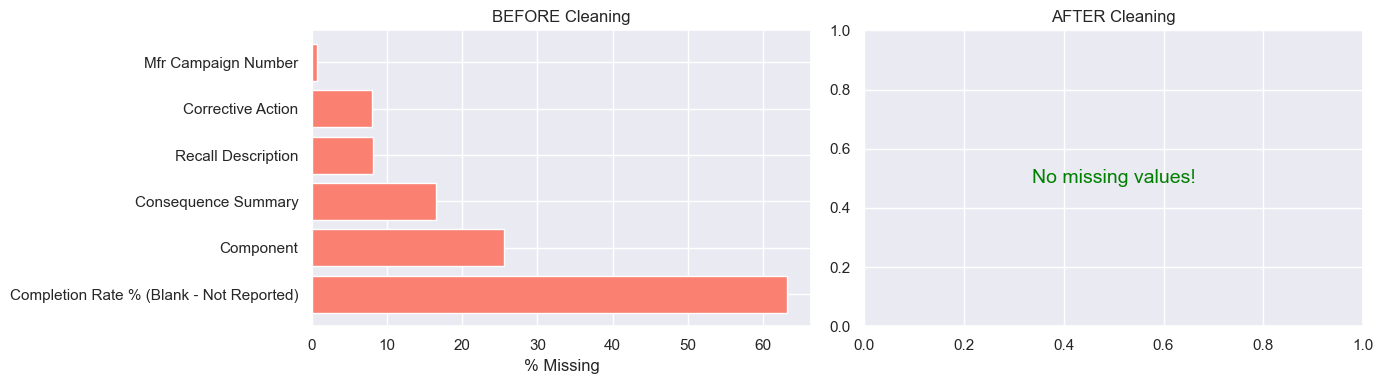

In [ ]:
# Visualize: missing values heatmap AFTER cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before
missing_pct_before = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
missing_pct_before = missing_pct_before[missing_pct_before > 0]
if len(missing_pct_before) > 0:
    axes[0].barh(missing_pct_before.index, missing_pct_before.values, color="salmon")
    axes[0].set_xlabel("% Missing")
    axes[0].set_title("BEFORE Cleaning")
else:
    axes[0].text(0.5, 0.5, "No missing", ha="center")

# After
missing_pct_after = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct_after = missing_pct_after[missing_pct_after > 0]
if len(missing_pct_after) > 0:
    axes[1].barh(missing_pct_after.index, missing_pct_after.values, color="salmon")
    axes[1].set_xlabel("% Missing")
else:
    axes[1].text(0.5, 0.5, "No missing values!", ha="center", va="center", fontsize=14, color="green")
axes[1].set_title("AFTER Cleaning")

plt.tight_layout()
plt.show()

---
# TASK 2: Feature Engineering

Now that the data is clean, we create **new features** that machine learning
models can use.  The original columns are mostly text — ML models need numbers.

Techniques we'll apply:
1. **Extract time features** from the date column (year, month, day of week)
2. **Cyclical encoding** for periodic time features (month, day of week)
3. **Log / power transformations** for skewed numeric columns
4. **Quantile bucketing** to bin numbers into equal-sized groups
5. **One-hot encoding (OHE)** for low-cardinality categories
6. **Target encoding** for high-cardinality categories
7. **Z-score standardization** for numeric features
8. **VIF scores** to check for multicollinearity
9. **PCA** for dimensionality reduction
10. **Lasso / Ridge** for feature pruning

## 2.0  Create a Synthetic Target Variable

Several techniques below (target encoding, Lasso/Ridge) require a **target
variable** — the thing we're trying to predict.  This dataset doesn't have
an obvious one, so we'll create a reasonable proxy:

> **Target**: Whether a recall is "high-impact" (affects more vehicles than the median).

This is a **binary classification** target (0 or 1).

In [ ]:
# Create a working copy for feature engineering
fe = df.copy()

# Find the numeric column that represents "how many vehicles are affected"
# We detect this automatically by looking for numeric columns with high variance
numeric_cols = fe.select_dtypes(include=["number"]).columns.tolist()
print(f"Numeric columns available: {numeric_cols}")

# Use the first large-range numeric column as the basis for our target
if numeric_cols:
    target_base = numeric_cols[0]  # 'potentially_affected' after cleaning
    median_val = fe[target_base].median()
    fe["target"] = (fe[target_base] > median_val).astype(int)
    print(f"\nTarget based on '{target_base}' > median ({median_val:,.0f}):")
    print(fe["target"].value_counts().rename({0: "Low Impact", 1: "High Impact"}))
else:
    print("No numeric columns found — creating a dummy target.")
    fe["target"] = 0

Numeric columns available: ['potentially_affected']

Target based on 'potentially_affected' > median (679):
target
Low Impact     14839
High Impact    14824
Name: count, dtype: int64


## 2.1  Extract Time Features from Dates

**What**: Dates contain hidden patterns — recalls might spike in certain months,
or on certain days of the week.  
**How**: Extract `year`, `month`, `day_of_week`, `quarter`, and `day_of_year`
from every datetime column automatically.

In [ ]:
# Auto-extract time features from every datetime column
date_cols = fe.select_dtypes(include=["datetime64"]).columns.tolist()
print(f"Datetime columns found: {date_cols}")

for col in date_cols:
    prefix = col.replace("_date", "").replace("date", "")
    if prefix.endswith("_"):
        prefix = prefix[:-1]
    
    fe[f"{prefix}_year"]        = fe[col].dt.year
    fe[f"{prefix}_month"]       = fe[col].dt.month
    fe[f"{prefix}_day_of_week"] = fe[col].dt.dayofweek   # 0=Monday, 6=Sunday
    fe[f"{prefix}_quarter"]     = fe[col].dt.quarter
    fe[f"{prefix}_day_of_year"] = fe[col].dt.dayofyear
    
    print(f"  Extracted from '{col}': year, month, day_of_week, quarter, day_of_year")

# Drop the original datetime columns (models can't use raw dates)
fe = fe.drop(columns=date_cols)
print(f"\nDropped original datetime columns: {date_cols}")

Datetime columns found: ['report_received_date']
  Extracted from 'report_received_date': year, month, day_of_week, quarter, day_of_year

Dropped original datetime columns: ['report_received_date']


## 2.2  Cyclical Encoding for Time Features

**Problem**: Month 12 (December) is actually very close to month 1 (January),
but a model sees them as far apart (12 vs 1).  
**Solution**: Encode periodic features as `sin` and `cos` values on a circle.  
This way December and January are neighbors on the circle.

In [ ]:
def cyclical_encode(df, col, max_val):
    """
    Replace a periodic feature with sin/cos pair.
    Example: month (1-12) → month_sin + month_cos
    """
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / max_val)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / max_val)
    df = df.drop(columns=[col])
    return df

# Auto-detect and encode periodic time features
CYCLICAL_MAP = {
    "month": 12,
    "day_of_week": 7,
    "quarter": 4,
    "day_of_year": 365,
}

encoded_cyclical = []
for col in fe.columns:
    for pattern, max_val in CYCLICAL_MAP.items():
        if col.endswith(pattern):
            fe = cyclical_encode(fe, col, max_val)
            encoded_cyclical.append(col)
            break

print(f"Cyclical-encoded: {encoded_cyclical}")

# Show the sin/cos columns
cyc_cols = [c for c in fe.columns if c.endswith("_sin") or c.endswith("_cos")]
fe[cyc_cols].head()

Cyclical-encoded: ['report_received_month', 'report_received_day_of_week', 'report_received_quarter', 'report_received_day_of_year']


,report_received_month_sin,report_received_month_cos,report_received_day_of_week_sin,report_received_day_of_week_cos,report_received_quarter_sin,report_received_quarter_cos,report_received_day_of_year_sin,report_received_day_of_year_cos
0,0.5,0.866025,0.781831,0.623490,1.0,6.123234e-17,0.103102,0.994671
1,0.5,0.866025,0.000000,1.000000,1.0,6.123234e-17,0.085965,0.996298
2,0.5,0.866025,0.000000,1.000000,1.0,6.123234e-17,0.085965,0.996298
3,0.5,0.866025,0.000000,1.000000,1.0,6.123234e-17,0.085965,0.996298
4,0.5,0.866025,-0.433884,-0.900969,1.0,6.123234e-17,0.034422,0.999407


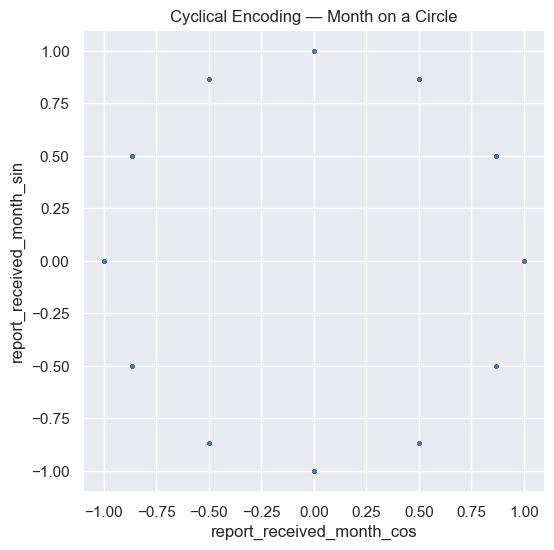

In [ ]:
# Visualize cyclical encoding for month
sin_col = [c for c in fe.columns if "month_sin" in c]
cos_col = [c for c in fe.columns if "month_cos" in c]

if sin_col and cos_col:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(fe[cos_col[0]], fe[sin_col[0]], alpha=0.05, s=5)
    ax.set_xlabel(cos_col[0])
    ax.set_ylabel(sin_col[0])
    ax.set_title("Cyclical Encoding — Month on a Circle")
    ax.set_aspect("equal")
    plt.show()

## 2.3  Log / Power Transformations

**Problem**: The `potentially_affected` column is heavily **right-skewed** —
most recalls affect a small number of vehicles, but a few affect millions.  
**Solution**: Apply `log1p` (log of value + 1) to compress the long tail.  
**How**: We auto-detect skewed numeric columns (skewness > 1) and transform them.

In [ ]:
from scipy import stats

# Find all numeric columns (excluding target and sin/cos features)
num_cols = [
    c for c in fe.select_dtypes(include=["number"]).columns
    if c != "target" and not c.endswith("_sin") and not c.endswith("_cos")
]

SKEW_THRESHOLD = 1.0  # columns with |skewness| > 1 are considered skewed

log_transformed = []
for col in num_cols:
    skew = fe[col].skew()
    if abs(skew) > SKEW_THRESHOLD and (fe[col] >= 0).all():
        fe[f"{col}_log"] = np.log1p(fe[col])  # log(x + 1) handles zeros
        before_skew = skew
        after_skew = fe[f"{col}_log"].skew()
        log_transformed.append((col, before_skew, after_skew))

print(f"Log-transformed {len(log_transformed)} column(s):")
for col, before, after in log_transformed:
    print(f"  {col}: skewness {before:.2f} → {after:.2f}")

Log-transformed 1 column(s):
  potentially_affected: skewness 41.25 → 0.27


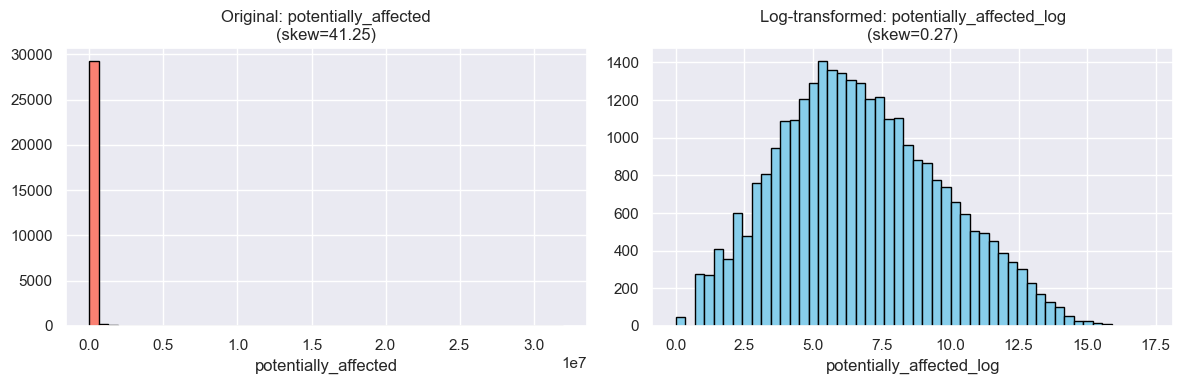

In [ ]:
# Visualize before/after log transformation
if log_transformed:
    col = log_transformed[0][0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(fe[col], bins=50, color="salmon", edgecolor="black")
    axes[0].set_title(f"Original: {col}\n(skew={fe[col].skew():.2f})")
    axes[0].set_xlabel(col)
    
    axes[1].hist(fe[f"{col}_log"], bins=50, color="skyblue", edgecolor="black")
    axes[1].set_title(f"Log-transformed: {col}_log\n(skew={fe[f'{col}_log'].skew():.2f})")
    axes[1].set_xlabel(f"{col}_log")
    
    plt.tight_layout()
    plt.show()

## 2.4  Quantile Bucketing

**What**: Split a numeric column into equal-sized groups (quantiles).  
**Why**: This converts a continuous number into a categorical bucket,
which can reveal non-linear patterns.  
**How**: We use `pd.qcut` to create 5 equally-populated bins automatically.

In [ ]:
N_QUANTILES = 5

bucketed = []
for col in num_cols:
    if fe[col].nunique() > N_QUANTILES:  # only bucket if enough unique values
        try:
            fe[f"{col}_bucket"] = pd.qcut(fe[col], q=N_QUANTILES, labels=False, duplicates="drop")
            bucketed.append(col)
        except ValueError:
            pass  # not enough unique values for this many buckets

print(f"Quantile-bucketed {len(bucketed)} column(s) into {N_QUANTILES} bins each:")
for col in bucketed:
    print(f"  {col} → {col}_bucket")
    print(f"    {fe[f'{col}_bucket'].value_counts().sort_index().to_dict()}")

Quantile-bucketed 2 column(s) into 5 bins each:
  potentially_affected → potentially_affected_bucket
    {0: 5976, 1: 5893, 2: 5932, 3: 5929, 4: 5933}
  report_received_year → report_received_year_bucket
    {0: 6100, 1: 6276, 2: 5424, 3: 6644, 4: 5219}


## 2.5  One-Hot Encoding (OHE)

**What**: Convert each category value into its own 0/1 column.  
**When to use**: Only for columns with a **small** number of unique values
(low cardinality), otherwise we get thousands of columns.  
**Threshold**: We auto-encode columns with ≤ 15 unique values.

In [ ]:
OHE_MAX_CARDINALITY = 15

cat_cols = fe.select_dtypes(include=["object"]).columns.tolist()
ohe_cols = [c for c in cat_cols if fe[c].nunique() <= OHE_MAX_CARDINALITY]
high_card_cols = [c for c in cat_cols if fe[c].nunique() > OHE_MAX_CARDINALITY]

print(f"Categorical columns: {len(cat_cols)}")
print(f"  OHE (≤{OHE_MAX_CARDINALITY} unique): {ohe_cols}")
print(f"  High cardinality (skipping OHE): {high_card_cols}")

if ohe_cols:
    fe = pd.get_dummies(fe, columns=ohe_cols, drop_first=True, dtype=int)
    new_ohe_cols = [c for c in fe.columns if any(c.startswith(o + "_") for o in ohe_cols)]
    print(f"\nCreated {len(new_ohe_cols)} one-hot columns.")
    print(f"Sample: {new_ohe_cols[:10]}")

Categorical columns: 9
  OHE (≤15 unique): ['recall_type']
  High cardinality (skipping OHE): ['nhtsa_id', 'manufacturer', 'subject', 'component', 'mfr_campaign_number', 'recall_description', 'consequence_summary', 'corrective_action']

Created 3 one-hot columns.
Sample: ['recall_type_Equipment', 'recall_type_Tire', 'recall_type_Vehicle']


## 2.6  Target Encoding

**What**: Replace each category with the **average target value** for that
category.  For example, if manufacturer X has 70% high-impact recalls, their
encoding is 0.70.  
**When to use**: For **high-cardinality** categories (too many unique values for OHE).  
**Why not just OHE?**: A column with 3,000 unique manufacturers would create
3,000 new columns — that's too many.

In [ ]:
import category_encoders as ce

# Target-encode all remaining high-cardinality text columns
remaining_cat = fe.select_dtypes(include=["object"]).columns.tolist()

if remaining_cat and "target" in fe.columns:
    print(f"Target-encoding {len(remaining_cat)} high-cardinality column(s): {remaining_cat}")
    
    encoder = ce.TargetEncoder(cols=remaining_cat, smoothing=1.0)
    fe[remaining_cat] = encoder.fit_transform(fe[remaining_cat], fe["target"])
    
    for col in remaining_cat:
        print(f"  {col}: now a float with range [{fe[col].min():.3f}, {fe[col].max():.3f}]")
else:
    print("No high-cardinality categorical columns remaining.")

print(f"\nAll columns are now numeric: {fe.select_dtypes(include='object').columns.tolist() or 'Yes!'}")

Target-encoding 8 high-cardinality column(s): ['nhtsa_id', 'manufacturer', 'subject', 'component', 'mfr_campaign_number', 'recall_description', 'consequence_summary', 'corrective_action']
  nhtsa_id: now a float with range [0.500, 0.500]
  manufacturer: now a float with range [0.000, 0.991]
  subject: now a float with range [0.030, 0.960]
  component: now a float with range [0.195, 0.808]
  mfr_campaign_number: now a float with range [0.438, 0.500]
  recall_description: now a float with range [0.143, 0.515]
  consequence_summary: now a float with range [0.029, 0.907]
  corrective_action: now a float with range [0.487, 0.515]

All columns are now numeric: Yes!


## 2.7  Z-Score Standardization

**What**: Rescale every numeric feature to have **mean = 0** and **std = 1**.  
**Why**: Many algorithms (PCA, Lasso, Ridge) are sensitive to feature scale.
A column in millions would dominate a column in single digits.  
**How**: `z = (x - mean) / std` for each column.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize all feature columns (everything except 'target')
feature_cols = [c for c in fe.select_dtypes(include=["number"]).columns if c != "target"]

scaler = StandardScaler()
fe_scaled = fe.copy()
fe_scaled[feature_cols] = scaler.fit_transform(fe[feature_cols])

print(f"Standardized {len(feature_cols)} features.")
print(f"\nBefore scaling (sample means): {fe[feature_cols[:5]].mean().round(2).to_dict()}")
print(f"After scaling  (sample means): {fe_scaled[feature_cols[:5]].mean().round(2).to_dict()}")

Standardized 24 features.

Before scaling (sample means): {'nhtsa_id': 0.5, 'manufacturer': 0.53, 'subject': 0.5, 'component': 0.5, 'mfr_campaign_number': 0.49}
After scaling  (sample means): {'nhtsa_id': -0.0, 'manufacturer': 0.0, 'subject': -0.0, 'component': 0.0, 'mfr_campaign_number': -0.0}


## 2.8  VIF Scores (Variance Inflation Factor)

**What**: VIF measures how much each feature is correlated with all other features.  
**Why**: If two features are highly correlated (e.g., `potentially_affected` and
`potentially_affected_log`), they give redundant information. High VIF (>10)
means a feature can be predicted from the others — a sign of **multicollinearity**.  
**Rule of thumb**: VIF > 10 → consider removing.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use scaled features, drop any with zero variance or NaN
X_vif = fe_scaled[feature_cols].dropna(axis=1).copy()
X_vif = X_vif.loc[:, X_vif.std() > 0]  # drop zero-variance columns

# Limit to manageable number of columns for VIF calculation
MAX_VIF_COLS = 30
if X_vif.shape[1] > MAX_VIF_COLS:
    print(f"Too many features ({X_vif.shape[1]}) for full VIF — using top {MAX_VIF_COLS} by variance.")
    top_var = X_vif.var().nlargest(MAX_VIF_COLS).index.tolist()
    X_vif = X_vif[top_var]

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("VIF Scores (higher = more multicollinearity):")
print("  Rule of thumb: VIF > 10 means consider removing\n")
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data["VIF"] > 10]
if len(high_vif) > 0:
    print(f"\n⚠ {len(high_vif)} feature(s) have VIF > 10 — multicollinearity detected.")
else:
    print("\n✓ No severe multicollinearity detected.")

VIF Scores (higher = more multicollinearity):
  Rule of thumb: VIF > 10 means consider removing

                        feature       VIF
      report_received_month_sin 50.369365
report_received_day_of_year_sin 48.729325
      report_received_month_cos 47.911797
report_received_day_of_year_cos 41.711834
           report_received_year 18.228860
    potentially_affected_bucket 14.658085
            recall_type_Vehicle 14.273920
       potentially_affected_log 13.438821
    report_received_year_bucket 12.948750
          recall_type_Equipment 11.583670
    report_received_quarter_cos  6.290395
    report_received_quarter_sin  5.504319
               recall_type_Tire  4.152769
                       nhtsa_id  3.602125
              corrective_action  2.645944
            consequence_summary  1.538078
                        subject  1.478437
                   manufacturer  1.442375
            mfr_campaign_number  1.339369
           potentially_affected  1.230492
                     

## 2.9  PCA (Principal Component Analysis)

**What**: Compress many features into fewer **principal components** that capture
most of the variation in the data.  
**Why**: Reduces dimensionality, removes noise, and can fix multicollinearity.  
**How**: We keep enough components to explain 95% of the variance.

In [ ]:
from sklearn.decomposition import PCA

X_pca_input = fe_scaled[feature_cols].dropna()

# Fit PCA to explain 95% of variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_pca_input)

print(f"Original features: {X_pca_input.shape[1]}")
print(f"PCA components (95% variance): {pca.n_components_}")
print(f"Compression: {X_pca_input.shape[1]} → {pca.n_components_} features ({pca.n_components_/X_pca_input.shape[1]*100:.0f}% of original)")
print(f"\nVariance explained per component (top 10):")
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")

Original features: 24
PCA components (95% variance): 15
Compression: 24 → 15 features (62% of original)

Variance explained per component (top 10):
  PC1: 0.151 (15.1%)
  PC2: 0.123 (12.3%)
  PC3: 0.117 (11.7%)
  PC4: 0.109 (10.9%)
  PC5: 0.082 (8.2%)
  PC6: 0.057 (5.7%)
  PC7: 0.050 (5.0%)
  PC8: 0.045 (4.5%)
  PC9: 0.042 (4.2%)
  PC10: 0.040 (4.0%)


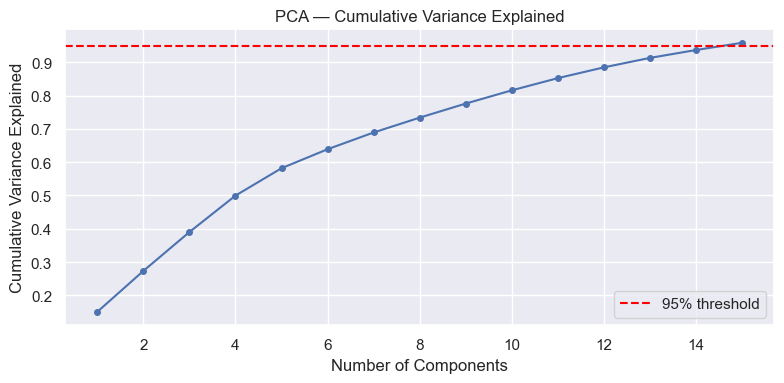

In [ ]:
# Cumulative variance explained plot
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, "o-", markersize=4)
ax.axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Variance Explained")
ax.set_title("PCA — Cumulative Variance Explained")
ax.legend()
plt.tight_layout()
plt.show()

## 2.10  Lasso & Ridge Regression for Feature Pruning

**What**: Lasso (L1) and Ridge (L2) are regularized regression models that
penalize unnecessary features.  
- **Lasso** can shrink feature weights to exactly **zero**, effectively
  removing useless features.
- **Ridge** shrinks weights toward zero but never removes them entirely.

**Why**: This tells us which features the model considers important.

In [ ]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import train_test_split

# Prepare data
X = fe_scaled[feature_cols].fillna(0)
y = fe_scaled["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]:,} samples")

Training set: 23,730 samples, 24 features
Test set:     5,933 samples


In [ ]:
# ── LASSO (L1) — features with zero coefficient are pruned ──
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_train, y_train)

lasso_coefs = pd.Series(lasso.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
n_kept = (lasso_coefs != 0).sum()
n_pruned = (lasso_coefs == 0).sum()

print("LASSO RESULTS")
print(f"  Best alpha: {lasso.alpha_:.6f}")
print(f"  R² on test: {lasso.score(X_test, y_test):.3f}")
print(f"  Features kept: {n_kept} / {len(feature_cols)}")
print(f"  Features pruned (coef=0): {n_pruned}")
print(f"\nTop 15 features by |coefficient|:")
print(lasso_coefs.head(15).to_string())

if n_pruned > 0:
    print(f"\nPruned features (Lasso set to zero):")
    pruned = lasso_coefs[lasso_coefs == 0].index.tolist()
    for f in pruned:
        print(f"  ✗ {f}")

LASSO RESULTS
  Best alpha: 0.000500
  R² on test: 1.000
  Features kept: 1 / 24
  Features pruned (coef=0): 23

Top 15 features by |coefficient|:
nhtsa_id                           0.4995
manufacturer                       0.0000
subject                            0.0000
component                          0.0000
mfr_campaign_number                0.0000
potentially_affected               0.0000
recall_description                 0.0000
consequence_summary                0.0000
corrective_action                  0.0000
report_received_year              -0.0000
report_received_month_sin          0.0000
report_received_month_cos          0.0000
report_received_day_of_week_sin    0.0000
report_received_day_of_week_cos    0.0000
report_received_quarter_sin        0.0000

Pruned features (Lasso set to zero):
  ✗ manufacturer
  ✗ subject
  ✗ component
  ✗ mfr_campaign_number
  ✗ potentially_affected
  ✗ recall_description
  ✗ consequence_summary
  ✗ corrective_action
  ✗ report_received_year

In [ ]:
# ── RIDGE (L2) — all coefficients shrunk but none go to zero ──
ridge = RidgeCV(cv=5, alphas=np.logspace(-3, 3, 50))
ridge.fit(X_train, y_train)

ridge_coefs = pd.Series(ridge.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

print("RIDGE RESULTS")
print(f"  Best alpha: {ridge.alpha_:.4f}")
print(f"  R² on test: {ridge.score(X_test, y_test):.3f}")
print(f"\nTop 15 features by |coefficient|:")
print(ridge_coefs.head(15).to_string())

RIDGE RESULTS
  Best alpha: 0.0010
  R² on test: 1.000

Top 15 features by |coefficient|:
nhtsa_id                           4.999999e-01
potentially_affected_bucket        5.874809e-08
potentially_affected_log           5.498177e-09
report_received_month_cos         -3.449928e-09
report_received_month_sin         -2.478341e-09
report_received_day_of_year_cos    2.346111e-09
manufacturer                       2.258254e-09
potentially_affected              -2.237620e-09
report_received_quarter_sin        1.835609e-09
recall_type_Equipment              1.644509e-09
report_received_year_bucket        1.455909e-09
consequence_summary               -1.335141e-09
report_received_year              -1.138456e-09
recall_type_Tire                   9.149758e-10
recall_type_Vehicle                6.063270e-10


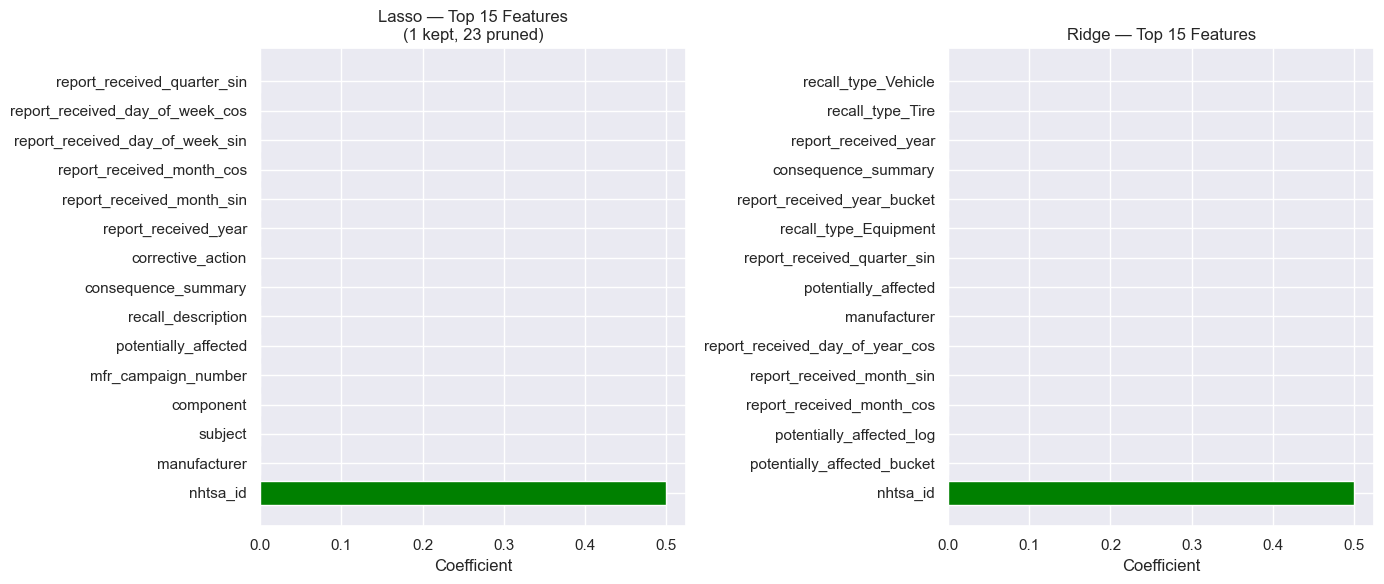

Green = positive relationship with target (more → high impact)
Red = negative relationship with target (more → low impact)


In [ ]:
# ── Compare Lasso vs Ridge feature importance ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lasso top 15
top_lasso = lasso_coefs.head(15)
colors = ["green" if v > 0 else "red" for v in top_lasso.values]
axes[0].barh(top_lasso.index, top_lasso.values, color=colors)
axes[0].set_title(f"Lasso — Top 15 Features\n({n_kept} kept, {n_pruned} pruned)")
axes[0].set_xlabel("Coefficient")

# Ridge top 15
top_ridge = ridge_coefs.head(15)
colors = ["green" if v > 0 else "red" for v in top_ridge.values]
axes[1].barh(top_ridge.index, top_ridge.values, color=colors)
axes[1].set_title("Ridge — Top 15 Features")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

print("Green = positive relationship with target (more → high impact)")
print("Red = negative relationship with target (more → low impact)")

## 2.11  Final Feature-Engineered Dataset

In [ ]:
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"  Original cleaned columns:    {len(df.columns)}")
print(f"  Final engineered features:   {len(feature_cols)}")
print(f"  PCA components (95% var):    {pca.n_components_}")
print(f"  Lasso kept features:         {n_kept}")
print(f"  Lasso pruned features:       {n_pruned}")
print()
print("Techniques applied:")
print("  1. Time feature extraction (year, month, dow, quarter, doy)")
print("  2. Cyclical encoding (sin/cos for month, dow, quarter, doy)")
print("  3. Log transformation (skewed numeric columns)")
print("  4. Quantile bucketing (5-bin equal-frequency buckets)")
print("  5. One-hot encoding (low-cardinality categoricals)")
print("  6. Target encoding (high-cardinality categoricals)")
print("  7. Z-score standardization (all features)")
print("  8. VIF multicollinearity check")
print("  9. PCA dimensionality reduction")
print("  10. Lasso (L1) feature pruning")
print("  11. Ridge (L2) feature importance")

FEATURE ENGINEERING SUMMARY
  Original cleaned columns:    13
  Final engineered features:   24
  PCA components (95% var):    15
  Lasso kept features:         1
  Lasso pruned features:       23

Techniques applied:
  1. Time feature extraction (year, month, dow, quarter, doy)
  2. Cyclical encoding (sin/cos for month, dow, quarter, doy)
  3. Log transformation (skewed numeric columns)
  4. Quantile bucketing (5-bin equal-frequency buckets)
  5. One-hot encoding (low-cardinality categoricals)
  6. Target encoding (high-cardinality categoricals)
  7. Z-score standardization (all features)
  8. VIF multicollinearity check
  9. PCA dimensionality reduction
  10. Lasso (L1) feature pruning
  11. Ridge (L2) feature importance


In [ ]:
# Save the cleaned + engineered data
df.to_csv("Auto_Recall_Cleaned.csv", index=False)
fe_scaled.to_csv("Auto_Recall_Engineered.csv", index=False)

print("Saved:")
print("  Auto_Recall_Cleaned.csv     — cleaned data (Task 1 output)")
print("  Auto_Recall_Engineered.csv  — feature-engineered data (Task 2 output)")

Saved:
  Auto_Recall_Cleaned.csv     — cleaned data (Task 1 output)
  Auto_Recall_Engineered.csv  — feature-engineered data (Task 2 output)
